In [3]:
import pandas as pd
df = pd.read_csv('letter-recognition.data', header=None)
# Assign column names (1 label + 16 features)
df.columns = ['letter','x1','x2','x3','x4','x5','x6','x7','x8',
              'x9','x10','x11','x12','x13','x14','x15','x16']
df.head()

,letter,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
# X = input features, y = output labels
X = df.drop('letter', axis=1)
y = df['letter']

# Convert letters (A–Z) → numbers (0–25)
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Standardize features (important for neural networks)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit + transform on train
X_test = scaler.transform(X_test)         # only transform on test

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Build Deep Neural Network
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(16,))) # Hidden layer 1
model.add(Dense(32, activation='relu')) # Hidden layer 2
model.add(Dense(26, activation='softmax')) # Output layer (26 classes → softmax)

# Compile model
model.compile(
    optimizer='adam',                           # optimizer
    loss='sparse_categorical_crossentropy',     # for integer labels
    metrics=['accuracy']                        # evaluation metric
)

# Display a summary of the model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │           858 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,026 (15.73 KB)

 Trainable params: 4,026 (15.73 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4994 - loss: 1.8830 - val_accuracy: 0.7031 - val_loss: 1.0687
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7417 - loss: 0.9044 - val_accuracy: 0.7713 - val_loss: 0.7985
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7918 - loss: 0.7136 - val_accuracy: 0.8019 - val_loss: 0.6660
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8200 - loss: 0.6047 - val_accuracy: 0.8300 - val_loss: 0.5834
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8441 - loss: 0.5283 - val_accuracy: 0.8388 - val_loss: 0.5335
Epoch 6/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8600 - loss: 0.4765 - val_accuracy: 0.8600 - val_loss: 0.4832
Epoch 7/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8724 - loss: 0.4319 - val_accuracy: 0.8744 - val_loss: 0.4418
Epoch 8/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8799 - loss: 0.3994 - val_accuracy: 0.

In [8]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)
print("Loss:", loss)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8947 - loss: 0.3516
Accuracy: 0.8947499990463257
Loss: 0.35157865285873413


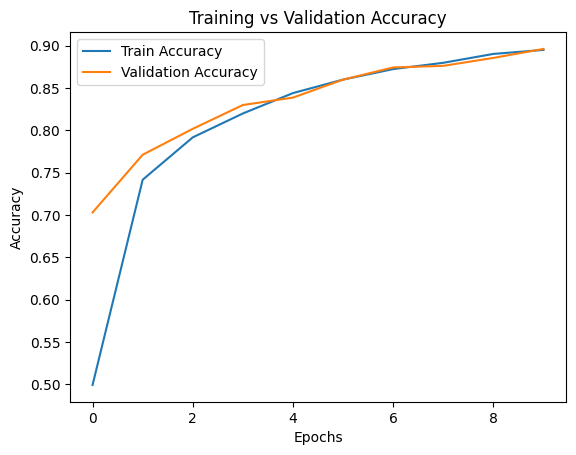

In [9]:
import matplotlib.pyplot as plt
# Plot training vs validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

In [10]:
from sklearn.metrics import confusion_matrix
# Confusion matrix (optional)
y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)
print(cm)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[144   0   0   1   0   0   0   0   0   0   0   0   2   0   0   0   0   1
    0   0   0   0   0   0   1   0]
 [  0 135   0   5   0   0   1   2   0   0   0   0   1   0   0   0   0   8
    0   1   0   0   0   0   0   0]
 [  0   0 122   0   1   0   3   1   0   0   0   0   0   0   4   0   1   2
    1   1   1   0   0   0   0   0]
 [  2   5   0 138   0   0   0   1   0   1   2   0   3   1   0   1   0   2
    0   0   0   0   0   0   0   0]
 [  0   0   3   0 127   1   6   0   0   0   1   0   0   0   0   0   0   0
    0   1   0   0   0   0   0   2]
 [  0   0   1   0   3 126   0   2   2   0   0   0   0   0   0   2   1   0
    1   2   0   0   0   0   0   0]
 [  0   1   5   2   0   0 138   0   0   0   4   3   0   0   3   0   0   1
    0   0   0   3   0   0   0   0]
 [  0   1   0   7   1   1   2 101   0   0   6   0   0   1   5   2   0  12
    0   0   2   0   0   0   3   0]
 [  0   0   0   3   0   1   0   0 128   6   0   2   0   0   0   1   0   1
    2   0   0